In [1]:
%matplotlib inline
from secsy import cubedsphere as cs
from secsy import CSplot
from secsy import get_SECS_J_G_matrices, get_SECS_B_G_matrices
import lompe
import apexpy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from resolution import get_resolution, basic_plot_resolution, add_coastlines_resolution, add_stations
import warnings
warnings.filterwarnings('ignore')
from my_utils import load_and_combine_supermag, add_qd_gridlines_cs

RE = 6371.2e3
RI = RE + 110e3

theta0=0.25 # for j_G matrix singularity limit

Epoch = 2025.

# make cubed sphere projection and grid
location = (-40,71)
orientation = 0
#L, W, Lres, Wres = 4500e3,3500e3,45,35
L, W, Lres, Wres = 4500e3,3500e3,100.0e3,100.0e3

projection = cs.CSprojection(location, orientation)
grid = cs.CSgrid(projection, L, W, Lres, Wres, R = RI, wshift=1.0)

shp = grid.shape

# make lompe model, used to compute gradient matrices in magnetic east/west (conductances don't matter for us)
model = lompe.Emodel(grid, Hall_Pedersen_conductance = (0,0), epoch=Epoch, ew_regularization_limit=(70,89))

# Define meridian
meridian_lat_qd = np.arange(60, 86+0.2, 0.2)
meridian_lon_qd = np.ones(len(meridian_lat_qd))*50

apex_obj = apexpy.Apex(date=datetime(2025, 2, 12), refh=110)
meridian_lat_geo, meridian_lon_geo = apex_obj.convert(meridian_lat_qd, meridian_lon_qd, 'qd', 'geo')

In [20]:
grid.shape

(32, 39)

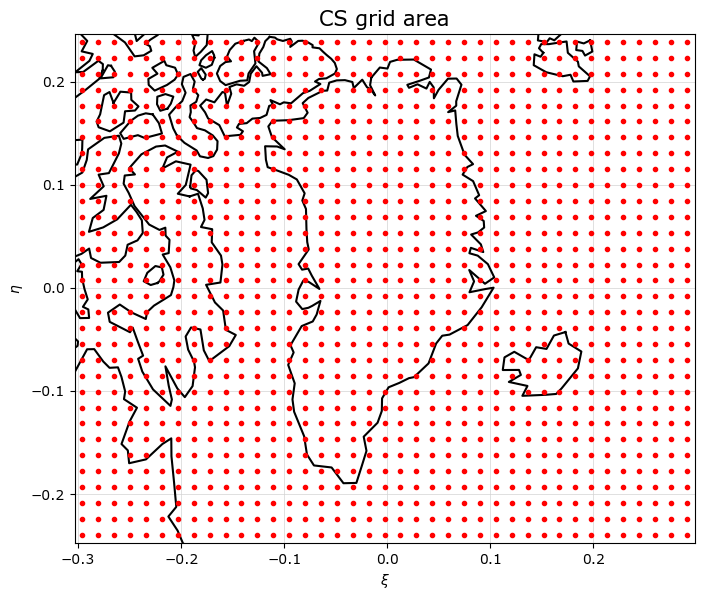

In [3]:
# plot grid and meridian
fig, ax = plt.subplots(figsize = (8, 7))
csax = CSplot(ax, grid, gridtype = 'cs')
csax.add_coastlines(color = 'black', resolution = '110m')
csax.plot(grid.lon.flatten(),grid.lat.flatten(), ls='',marker='.',color='red')
csax.ax.set_title('CS grid area', size = 15)
plt.show()

In [2]:
stations = np.load('stations_supermag.npy', allow_pickle=True)
times = np.load('concurrent_times_supermag.npy',allow_pickle=True)

In [3]:
times_sup = np.load('concurrent_times_supermag.npy',allow_pickle=True)
times_dtu = np.load('concurrent_times_dtu_minute.npy',allow_pickle=True)
times = np.intersect1d(times_sup, times_dtu)

In [4]:
times[1500]

np.datetime64('2023-03-25T12:33:00.000000')

In [4]:
# load supermag data
df_mag = load_and_combine_supermag('20230326', stations, base_dir='supermag_downloads/yearly_BASELINE')
df_mag['time'] = pd.to_datetime(df_mag['time'])
df1 = df_mag[df_mag['time']==datetime(2023,3,25,12,33,0)]
df1

,time,ext,iaga,dbn_geo,dbe_geo,dbz_geo
706260,2023-03-25 12:33:00,60.0,BJN,78.519339,-8.645821,-233.250204
706261,2023-03-25 12:33:00,60.0,DMH,-168.899388,97.958418,-90.048510
706262,2023-03-25 12:33:00,60.0,GDH,-40.453328,154.005118,-22.542682
706263,2023-03-25 12:33:00,60.0,HOP,-93.390690,27.464791,-182.972413
706264,2023-03-25 12:33:00,60.0,HOV,-5.024703,-20.618120,29.883376
706265,2023-03-25 12:33:00,60.0,HRN,-125.442486,35.998232,-161.290787
706266,2023-03-25 12:33:00,60.0,IQA,-92.156397,90.380371,-16.988634
706267,2023-03-25 12:33:00,60.0,JAN,89.815317,36.817315,-0.025914
706268,2023-03-25 12:33:00,60.0,KUV,-174.737210,106.633117,155.531822
706269,2023-03-25 12:33:00,60.0,LRV,2.634333,9.688641,19.536165


In [5]:
ss = slice(0, -1, 2) # downsample for vector plots
la, lo = grid.lat_mesh[ss, ss], grid.lon_mesh[ss, ss]

# matrices that calculate currents (for plotting vectors):
Gej, Gnj = get_SECS_J_G_matrices(la, lo, grid.lat, grid.lon, singularity_limit = theta0 * np.pi / 180 * RI)
Gej_grid, Gnj_grid = get_SECS_J_G_matrices(grid.lat_mesh, grid.lon_mesh, grid.lat, grid.lon, singularity_limit = theta0 * np.pi / 180 * RI)
# and magnetic field on ground (evaluated on the full "mesh" grid, not downsampled):
GeB, GnB, GuB = get_SECS_B_G_matrices(grid.lat_mesh, grid.lon_mesh, RE, grid.lat, grid.lon)

In [6]:
df_loc = pd.read_csv('SuperMAG_stations.csv')

df_loc = df_loc[df_loc['IAGA'].isin(stations)]
df_loc = df_loc.sort_values(by='IAGA')
lon_mag = df_loc['GLON'].values
lat_mag = df_loc['GLAT'].values

In [7]:
# find SuperMAG magnetometers that are in the grid:
xi_mag, eta_mag = projection.geo2cube(lon_mag, lat_mag)

GeB_mag, GnB_mag, GuB_mag = get_SECS_B_G_matrices(lat_mag, lon_mag, RE, grid.lat, grid.lon)
Be_mag, Bn_mag, Bu_mag = df1['dbe_geo'].values, df1['dbn_geo'].values, -df1['dbz_geo'].values #note sign change on z component

print('Dataset consists of {} magnetometers'.format(len(xi_mag)))

Dataset consists of 20 magnetometers


In [8]:
# first we stack the G matrices and data vectors.
depth = 400e3 # depth where Br = 0 [m]
GeB_mirror,     GnB_mirror,     GuB_mirror     = get_SECS_B_G_matrices(grid.lat_mesh, grid.lon_mesh, RE, grid.lat, grid.lon, induction_nullification_radius = RE - depth)
GeB_mag_mirror, GnB_mag_mirror, GuB_mag_mirror = get_SECS_B_G_matrices(lat_mag      , lon_mag      , RE, grid.lat, grid.lon, induction_nullification_radius = RE - depth)

# G matrix for the mirror current method:
G_mirror = np.vstack((GeB_mag_mirror, GnB_mag_mirror, GuB_mag_mirror)) # shape: (3*N, grid.size)
d = np.hstack((Be_mag, Bn_mag, Bu_mag)) * 10**(-9)   # shape: (3*N)

# Approach number 2: East-west minimization
Le, Ln, LTLe, LTLn = model.compute_L_matrices(grid) # get matrices that calculate MAGNETIC eastward and northward components of gradient
LTL = LTLe

T0, T1 = 8e-24, 1e-21 # regularization parameters from Walker
R = T0 * np.eye(grid.size) + T1 * LTL # regularization matrix

# using inversion approach (2):
GTG_mirror, GTd_mirror = G_mirror.T.dot(G_mirror), G_mirror.T.dot(d) # we multiply the set of equations by G_mirror transpose
I_mirror = np.linalg.lstsq(GTG_mirror + R, GTd_mirror, rcond = 0)[0]

gridtype must be 'geo', 'km' or 'cs' to be added. 'dipole' and 'apex' will soon be available.
gridtype must be 'geo', 'km' or 'cs' to be added. 'dipole' and 'apex' will soon be available.
gridtype must be 'geo', 'km' or 'cs' to be added. 'dipole' and 'apex' will soon be available.


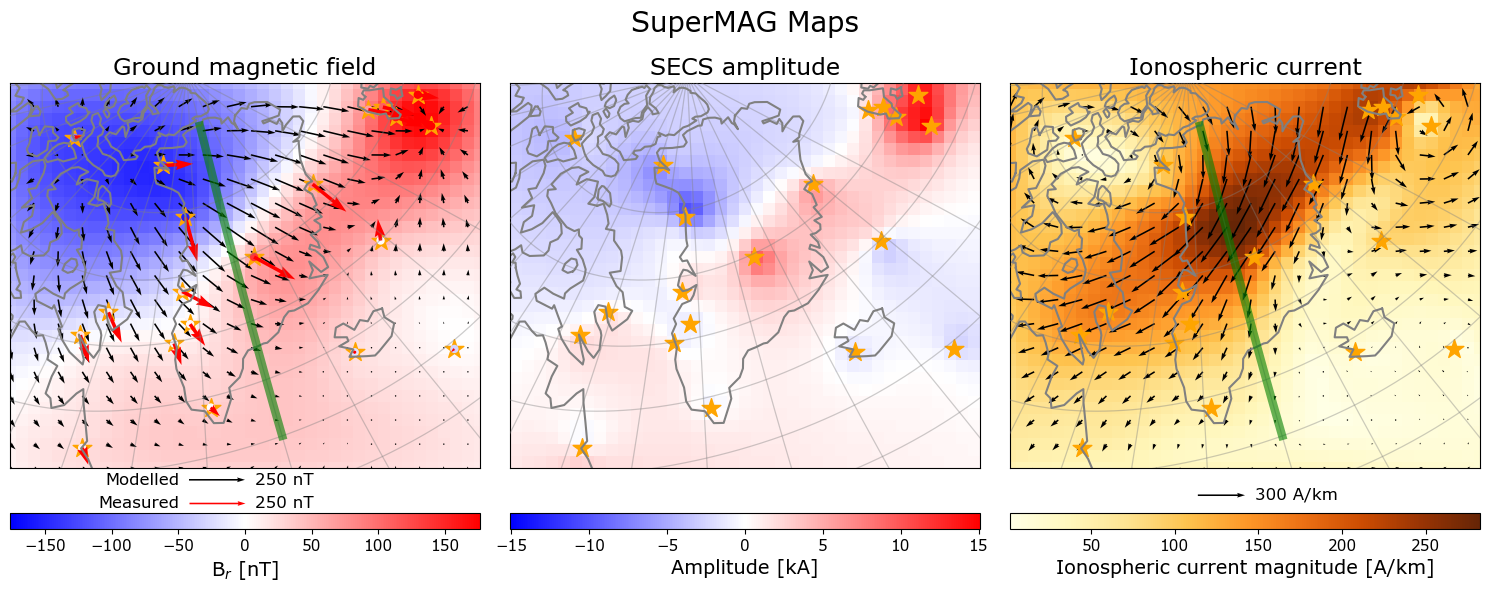

In [42]:
model_vector = I_mirror

# Plot the original and the solutions
fig, axes = plt.subplots(ncols=3, nrows=1, figsize=(15, 10))
# Add space at the bottom for colorbars
fig.subplots_adjust(bottom=0.15, wspace=0.3)

csaxes = [CSplot(ax, grid, gridtype=None) for ax in axes.flatten()]

# --- Subplot 0: Ground magnetic field ---
Be, Bn, Bu = (GeB.dot(model_vector).reshape(grid.lat_mesh.shape)*1e9,
              GnB.dot(model_vector).reshape(grid.lat_mesh.shape)*1e9,
              GuB.dot(model_vector).reshape(grid.lat_mesh.shape)*1e9)

mag_model_i = np.sqrt(Be**2 + Bn**2).max()
mag_data_i  = np.sqrt(Be_mag**2 + Bn_mag**2).max()
quiver_scale_B = max(mag_model_i, mag_data_i) *10 # tune multiplier as needed

qv0 = csaxes[0].quiver(Be[ss, ss].flatten(), Bn[ss, ss].flatten(), lo, la, scale=quiver_scale_B)
pm0 = csaxes[0].pcolormesh(grid.lon_mesh, grid.lat_mesh, Bu,
                            cmap=plt.cm.bwr,
                            vmin=-np.abs(Bu.max()), vmax=np.abs(Bu.max()),
                            zorder=0)

csaxes[0].ax.scatter(xi_mag, eta_mag, c='orange', s=200, marker='*')
csaxes[0].ax.scatter(
    xi_mag, eta_mag, c=Bu_mag,
    s=25, cmap=plt.cm.bwr, vmin=-np.abs(Bu.max()), vmax=np.abs(Bu.max())
)
csaxes[0].quiver(
    Be_mag.flatten(), Bn_mag.flatten(),
    lon_mag, lat_mag,
    color='red', scale=quiver_scale_B
)

csaxes[0].plot(meridian_lon_geo, meridian_lat_geo, lw=6, color='green', alpha=0.6, zorder=10)

# --- Subplot 1: SECS amplitude ---
pm1 = csaxes[1].pcolormesh(grid.lon_mesh, grid.lat_mesh,
                            I_mirror.reshape(shp)*0.001,
                            cmap=plt.cm.bwr,
                            vmin=-np.abs((I_mirror*0.001).max()), vmax=np.abs((I_mirror*0.001).max()))
je, jn = Gej.dot(model_vector).reshape(la.shape)*1000, Gnj.dot(model_vector).reshape(la.shape)*1000

# --- Subplot 2: Ionospheric current ---
je_grid, jn_grid = Gej_grid.dot(model_vector)*1000, Gnj_grid.dot(model_vector)*1000
j_tot = np.sqrt(je_grid**2 + jn_grid**2)
pm2 = csaxes[2].pcolormesh(grid.lon_mesh, grid.lat_mesh,
                            j_tot.reshape(grid.lat_mesh.shape),
                            cmap=plt.cm.YlOrBr,
                            vmin=np.abs(j_tot.min()), vmax=np.abs(j_tot.max()))
qv2 = csaxes[2].quiver(je, jn, lo, la)
csaxes[2].plot(meridian_lon_geo, meridian_lat_geo, lw=6, color='green', alpha=0.6, zorder=10)

# --- Titles ---
csaxes[0].ax.set_title('Ground magnetic field', size=17)
csaxes[1].ax.set_title('SECS amplitude', size=17)
csaxes[2].ax.set_title('Ionospheric current', size=17)

# --- Scatter & coastlines ---
csaxes[0].add_coastlines(color='grey', resolution='110m')
for a in csaxes[1:]:
    a.ax.scatter(xi_mag, eta_mag, c='orange', s=200, marker='*')
    a.add_coastlines(color='grey', resolution='110m')

# --- Colorbars below each subplot ---
for ax, pm, label in zip(axes, [pm0, pm1, pm2],
                         ['B$_r$ [nT]', 'Amplitude [kA]', 'Ionospheric current magnitude [A/km]']):
    cbar = fig.colorbar(pm, ax=ax, orientation='horizontal',
                        pad=0.05, fraction=0.046, aspect=30)
    cbar.set_label(label, size=14)
    cbar.ax.tick_params(labelsize=11)

# --- Quiverkeys ---
# Adjust U (reference arrow length) to a round number representative of your data
qk0 = csaxes[0].ax.quiverkey(qv0, X=0.5, Y=-0.03, U=250,
                               label='250 nT', labelpos='E', fontproperties={'size': 12})
qk0 = csaxes[0].ax.quiverkey(qv0, X=0.5, Y=-0.09, U=250,
                               label='250 nT', labelpos='E', color='red', fontproperties={'size': 12})
csaxes[0].ax.text(0.36, -0.03, 'Modelled',
        ha='right',          # right-align so it ends just left of the arrow
        va='center',
        transform=csaxes[0].ax.transAxes,
        fontsize=12,  # match quiverkey font size
        color='black')
csaxes[0].ax.text(0.36, -0.09, 'Measured',
        ha='right',          # right-align so it ends just left of the arrow
        va='center',
        transform=csaxes[0].ax.transAxes,
        fontsize=12,  # match quiverkey font size
        color='black')
qk2 = csaxes[2].ax.quiverkey(qv2, X=0.5, Y=-0.07, U=300,
                               label='300 A/km', labelpos='E', fontproperties={'size': 12})
fig.suptitle('SuperMAG Maps', fontsize=20, y=0.59)

EXTENT = [-90, 10, 53, 85] 
for csa in csaxes:
    add_qd_gridlines_cs(
        csa,
        apex_obj,
        qlat_lines=range(50, 85, 5),
        qlon_lines=range(-60, 100, 10),
        extent=EXTENT,
        lat_color='grey',
        lon_color='grey',
        linewidth=0.9,
        alpha=0.4,
        linestyle='-',
        label_gridlines=False,
    )

plt.tight_layout()
plt.show()

In [9]:
#Model resolution matrix
Rm = np.linalg.lstsq(GTG_mirror + R, GTG_mirror, rcond = 0)[0]

# Spatial resolution in cross-track and along-track directions
xi_FWHM, eta_FWHM, xi_flag, eta_flag = get_resolution(Rm, grid)
ef = (xi_flag==1) & (eta_flag==1)
#data_product['xi_FWHM'] = xi_FWHM # cross-track resolution
#data_product['eta_FWHM'] = eta_FWHM # along-track resolution

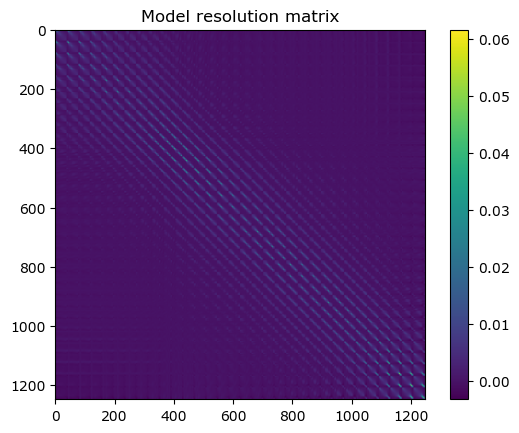

In [10]:
plt.imshow(Rm)
plt.colorbar()
plt.title('Model resolution matrix')
plt.show()

In [45]:
grid.shape

(32, 39)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


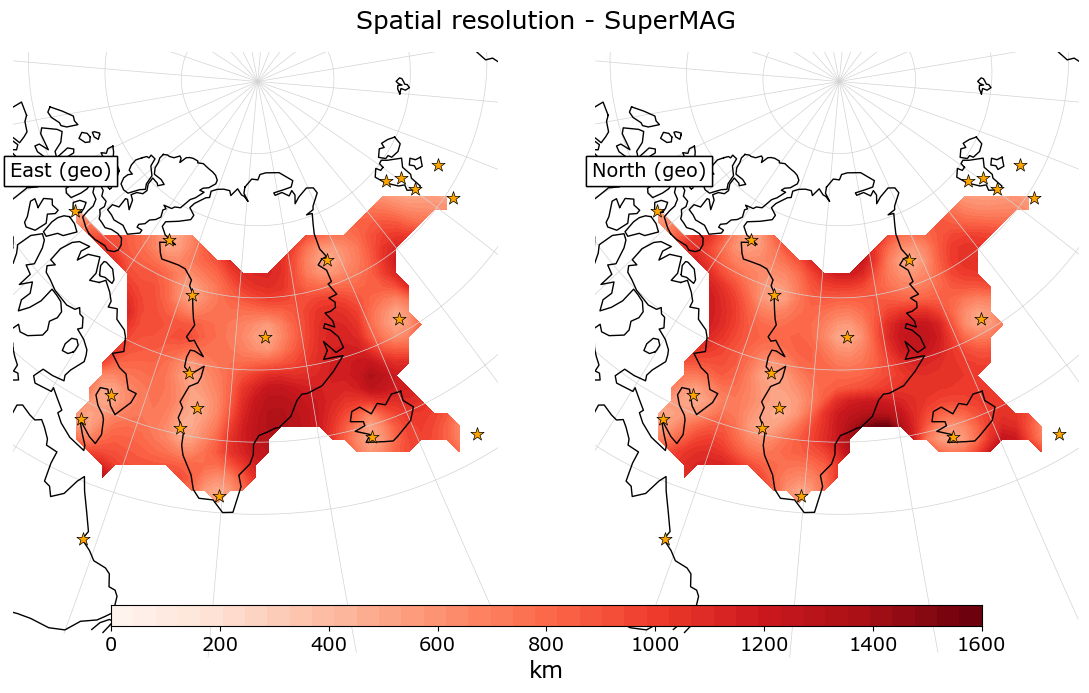

In [ ]:
# --- After your existing call ---
axs, cax = basic_plot_resolution(xi_FWHM, eta_FWHM, ef, grid, obs=[], RI=RI, PD=[], apex_obj=apex_obj, title='Spatial resolution - SuperMAG', vmax=1600)
cax.set_xlabel('km', fontsize=16)
#cax.figure.axes[2].set_position([0.1, 0.1, 0.8, 0.03]) #change second value to move cbar up/down
cax.tick_params(axis='x', labelsize=14)

add_coastlines_resolution(axs, grid, linewidth=1, color='black', zorder=5)
add_stations(axs, xi_mag, eta_mag, s=100, color='orange', marker='*')

In [33]:
np.save('xi_FWHM_sup2.npy',xi_FWHM)
np.save('eta_FWHM_sup2.npy',eta_FWHM)

In [24]:
print(ef.shape, ef.dtype)

(32, 39) bool


In [48]:
xi_FWHM.min(), eta_FWHM.min()

(np.float64(315.518726694803), np.float64(349.11678589547677))